# UWM pushT — Policy-mode sampling experiments

Studying the **policy marginal** `p(a_t | o_t)` of the unified world model: given
a clean observation history, sample the next action(s). Concretely this is the
**action-pretraining** corner of the UWM — the horizon *state* stream is held at
pure noise (we don't know the future) while the *action* stream is integrated
from noise to clean, conditioned on the clean observation context (see
`marginal_action_sampler` in `sampling_new.py`, which this notebook mirrors).

**Why.** The end goal is **MCTS planning** where tree *nodes* are states and tree
*edges* are short action rollouts drawn from a prior policy `π_prior`. For the
tree to explore, `π_prior` must produce **diverse but plausible** actions. So the
central question here is: **how do we control the entropy / diversity of
`p(a_t | o_t)`?**

### Experiments
- **Part I — Sanity & calibration.** Sample `p(a_t | o_t)` at several states;
  compare the action cloud to the dataset's actual next action.
- **Part II — Context-noise injection.** Inject noise into the observation
  context and measure whether action entropy rises — both *honest* (model is told
  the context is noisy) and *mismatched* (context corrupted but claimed clean).
- **Part III — Other diversity knobs.** Action-prior temperature and the number
  of diffusion steps.
- **Part IV — Toward MCTS edges.** Short open-loop action rollouts and their
  divergence.

**Convention.** The denoiser is an *x-predictor* at cleanness `tau`
(`tau=0` → pure noise, `tau=1` → clean). Flow-matching velocity
`v = (x_hat - x) / (1 - tau)`, integrated with forward Euler over `K` steps.
Noise levels reach the model as quantized indices in `[0, num_noise_levels - 1]`.
This checkpoint is `horizon_aware=False` (purely causal); policy mode is in-dist.

## 1. Setup

In [8]:
%load_ext autoreload
%autoreload 2
import math
import torch
import numpy as np
import matplotlib.pyplot as plt

from hydra import initialize, compose
from omegaconf import OmegaConf

from dreamerv4uwm.models.utils import load_tokenizer, load_denoiser
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.sampling_new import make_is_horizon, _quantize_tau_to_idx, marginal_action_sampler

torch.manual_seed(0)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
resolution = (256, 256)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
# --- Lightweight experiment knobs -------------------------------------------
# Dial these DOWN for fast iteration, UP for final/publication figures.
# Every experiment cell below reads these globals, so one edit here rescales
# the whole notebook's cost.
N_SAMPLES = 96    # action samples per p(a|o) estimate   (was 256)
K_STEPS   = 12    # Euler / diffusion steps              (was 32)
MAX_BATCH = 96    # GPU batch cap (>= N_SAMPLES => single forward batch)

# Sweep grids (fewer points = faster). Add points back when a trend looks real.
STATES = [24, 40]            # window starts -> decisions at t0+T_ctx
NOISES = [0.0, 0.2, 0.4]     # context-noise levels (Part II)
TEMPS  = [0.5, 1.0, 2.0]     # action-prior temperature (Part III)
KS     = [4, 12, 32]         # diffusion-step sweep (Part III)
ROLL_H, ROLL_NB = 8, 12      # rollout horizon / count (Part IV)

print(f'lightweight: N_SAMPLES={N_SAMPLES}  K_STEPS={K_STEPS}')

lightweight: N_SAMPLES=96  K_STEPS=12


## 2. Config & checkpoints

`pushT-large` + `horizon_aware=false` to match the post-trained checkpoint.

In [10]:
with initialize(version_base=None, config_path='../scripts/config'):
    cfg = compose(config_name='dynamics/pushT-large', overrides=['denoiser.horizon_aware=false'])

cfg.dynamics_ckpt = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/blockcausal/pushT-post-train/97500.pt'
cfg.tokenizer_ckpt = '/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer/pushT.pt'
print('n_actions:', cfg.denoiser.n_actions, '| num_noise_levels:', cfg.denoiser.num_noise_levels)

n_actions: 2 | num_noise_levels: 128


## 3. Load denoiser + tokenizer

In [11]:
denoiser = load_denoiser(cfg, device, max_num_forward_steps=300).eval().cuda()
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300).eval().cuda()
print('frame_id_embedder:', denoiser.model.frame_id_embedder)

frame_id_embedder: None


## 4. Held-out window → latents

Encode one fixed 64-frame window. A **state** for the policy is a clean context
slice `o_{t0 : t0+T_ctx}`; the action we predict is the next one, `a_{t0+T_ctx}`,
whose dataset value is the calibration target.

In [12]:
DATA_PATH = '/home/mim-server/datasets/pushT/h5/play'
dataset = ShardedHDF5Dataset(data_dir=DATA_PATH, window_size=64, stride=1,
                             split='train', train_fraction=0.9, split_seed=123)

batch = dataset[1234]  # fixed window
from torch.nn.functional import interpolate
imgs = interpolate(batch['image'], resolution).to(device)[None]
actions = batch['action'][:, :cfg.denoiser.n_actions][None].to(device)   # (1, T, n_act)
with torch.no_grad(), torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    latents = tokenizer.encode(imgs)
latents = latents.float()
print('latents:', tuple(latents.shape), '| actions:', tuple(actions.shape))

T_ctx = 8   # observation-history length defining a 'state'


def make_state(t0, T_ctx=T_ctx):
    '''Return (ctx_latents, ctx_actions, gt_next_action) for a decision at t0+T_ctx.'''
    ctx_z = latents[:, t0:t0 + T_ctx].clone()
    ctx_a = actions[:, t0:t0 + T_ctx].clone()
    gt_next = actions[:, t0 + T_ctx].clone()        # (1, n_act)
    return ctx_z, ctx_a, gt_next

Train split: 64694 windows from 11 episodes
latents: (1, 64, 256, 32) | actions: (1, 64, 2)


## 5. Helpers — decoding, scatter, entropy

Actions are 2-D for pushT, so we can scatter `p(a_t|o_t)` directly. Diversity is
summarized by per-dim std, the Gaussian differential entropy
`H = 0.5·log((2πe)^d · |Σ|)`, and mean pairwise distance.

In [13]:
@torch.no_grad()
def decode_frame(lat_1frame):
    """Decode a single latent frame (1, 1, N_lat, D_lat) -> (H, W, 3) uint8."""
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        v = tokenizer.decode(lat_1frame.to(device)).float().clamp(0, 1)
    return (v[0, 0].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)


def gaussian_entropy(samples):
    """Differential entropy (nats) of a Gaussian fit to samples (B, d)."""
    x = samples.detach().cpu().double()
    d = x.shape[1]
    cov = torch.cov(x.T).reshape(d, d) + 1e-9 * torch.eye(d, dtype=torch.double)
    logdet = torch.linalg.slogdet(cov)[1].item()
    return 0.5 * (d * math.log(2 * math.pi * math.e) + logdet)


def summarize(samples):
    """Dict of diversity stats for action samples (B, d)."""
    x = samples.detach().cpu()
    B = x.shape[0]
    std = x.std(0)
    # mean pairwise L2 (subsample for speed if needed)
    idx = torch.randperm(B)[:min(B, 256)]
    xs = x[idx]
    pdist = torch.cdist(xs, xs)
    mpd = pdist.sum() / (xs.shape[0] * (xs.shape[0] - 1))
    return dict(std=std.numpy(), trace_std=float(std.sum()),
                entropy=gaussian_entropy(samples), mean_pairwise=float(mpd))


def plot_action_clouds(clouds, gt=None, title=None, lims=0.25, ax=None):
    """Scatter several labeled 2-D action clouds. clouds: dict label -> (B, 2) array."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(1, 1, figsize=(5.2, 5.2))
    for lab, pts in clouds.items():
        ax.scatter(pts[:, 0], pts[:, 1], s=8, alpha=0.35, label=lab)
    if gt is not None:
        ax.scatter([gt[0]], [gt[1]], marker='*', s=260, c='k', edgecolor='w',
                   zorder=5, label='dataset next action')
    ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6)
    ax.set_xlim(-lims, lims); ax.set_ylim(-lims, lims); ax.set_aspect('equal')
    ax.set_xlabel('action dim 0'); ax.set_ylabel('action dim 1')
    ax.legend(fontsize=8, loc='upper right')
    if title:
        ax.set_title(title, fontsize=11)
    if own:
        plt.tight_layout(); plt.show()

## 6. Policy sampler — `policy_sample`

Mirrors `marginal_action_sampler`: clean observation context, horizon **state
held at pure noise**, horizon **action integrated** from its prior to clean. The
only addition is an explicit **context-noise-injection** knob:

- `ctx_noise` ∈ [0, 1] — noise level mixed into the *observation* context
  (`o ← (1-τ)·ε + τ·o`, `τ = 1 - ctx_noise`).
- `ctx_noise_honest` — if `True`, the context's `obs_sigma` index is set to the
  injected level (model *knows* it's uncertain); if `False`, the context is
  corrupted but still announced as clean (model is confidently wrong).
- `action_noise_std` — scale of the action prior (temperature-like).

Drawing `n_samples` independent priors and integrating gives `n_samples` draws
from `p(a | o)`. Returns actions `(n_samples, horizon, n_act)`.

In [14]:
@torch.no_grad()
def _policy_sample_chunk(denoiser, ctx_z, ctx_a, horizon, B, K,
                         ctx_noise, ctx_noise_honest, action_noise_std, clean_ctx_tau):
    """One memory-bounded batch of B policy samples (no seeding here)."""
    d = denoiser.cfg.denoiser
    N, N_lat, D_lat, n_act = (d.num_noise_levels, d.num_latent_tokens,
                              d.latent_dim, d.n_actions)
    device = ctx_z.device
    Tc, Th = ctx_z.shape[1], horizon
    T = Tc + Th

    cz = ctx_z.expand(B, -1, -1, -1).contiguous()
    ca = ctx_a.expand(B, -1, -1).contiguous()
    step_idx = torch.zeros((B, T), dtype=torch.long, device=device)
    is_hor = make_is_horizon(T, ctx_len=Tc, device=device)   # ignored (horizon_aware=false)

    # --- context: inject obs noise; actions kept clean ---
    tau_ctx = 1.0 - ctx_noise
    z = torch.empty(B, T, N_lat, D_lat, device=device)
    a = torch.empty(B, T, n_act, device=device)
    z[:, :Tc] = (1.0 - tau_ctx) * torch.randn_like(cz) + tau_ctx * cz
    a[:, :Tc] = ca
    ctx_obs_idx = _quantize_tau_to_idx(tau_ctx if ctx_noise_honest else clean_ctx_tau, N)
    ctx_act_idx = _quantize_tau_to_idx(clean_ctx_tau, N)

    # --- horizon: state held at pure noise; action integrated from its prior ---
    z[:, Tc:] = torch.randn(B, Th, N_lat, D_lat, device=device)
    a[:, Tc:] = action_noise_std * torch.randn(B, Th, n_act, device=device)

    cur, dt = 0.0, 1.0 / K
    for _ in range(K):
        obs_sigma = torch.full((B, T), ctx_obs_idx, dtype=torch.long, device=device)
        act_sigma = torch.full((B, T), ctx_act_idx, dtype=torch.long, device=device)
        obs_sigma[:, Tc:] = 0                              # horizon state: pure noise (held)
        act_sigma[:, Tc:] = _quantize_tau_to_idx(cur, N)  # horizon action: current cleanness
        _, a_hat, _ = denoiser(
            noisy_act=a, noisy_obs=z,
            obs_sigma_idx=obs_sigma, obs_step_idx=step_idx,
            act_sigma_idx=act_sigma, act_step_idx=step_idx, is_horizon=is_hor,
        )
        a_hat = a_hat.squeeze(-2)
        denom = max(1.0 - cur, 1e-5)
        a[:, Tc:] = a[:, Tc:] + ((a_hat - a) / denom * dt)[:, Tc:]
        cur += dt
    return a[:, Tc:]   # (B, horizon, n_act)


@torch.no_grad()
def policy_sample(denoiser, ctx_z, ctx_a, horizon=1, n_samples=256, K=32,
                  ctx_noise=0.0, ctx_noise_honest=True, action_noise_std=1.0,
                  clean_ctx_tau=0.999, seed=0, max_batch=64):
    """Sample p(a | o) under the action-pretraining (policy) protocol.

    Splits `n_samples` into chunks of at most `max_batch` so peak GPU memory
    stays bounded (the per-call RNG sequence is identical for fixed
    n_samples/max_batch, preserving the paired-seed design across sweeps).
    Returns actions (n_samples, horizon, n_act).
    """
    if seed is not None:
        torch.manual_seed(seed)
    outs, done = [], 0
    while done < n_samples:
        b = min(max_batch, n_samples - done)
        outs.append(_policy_sample_chunk(
            denoiser, ctx_z, ctx_a, horizon, b, K,
            ctx_noise, ctx_noise_honest, action_noise_std, clean_ctx_tau))
        done += b
    return torch.cat(outs, 0)

# Part I — Sanity & calibration

Sample `p(a_t | o_t)` at a few states and overlay the dataset's actual next
action. We expect the action cloud to sit near the dataset action with a spread
reflecting the policy's intrinsic stochasticity.

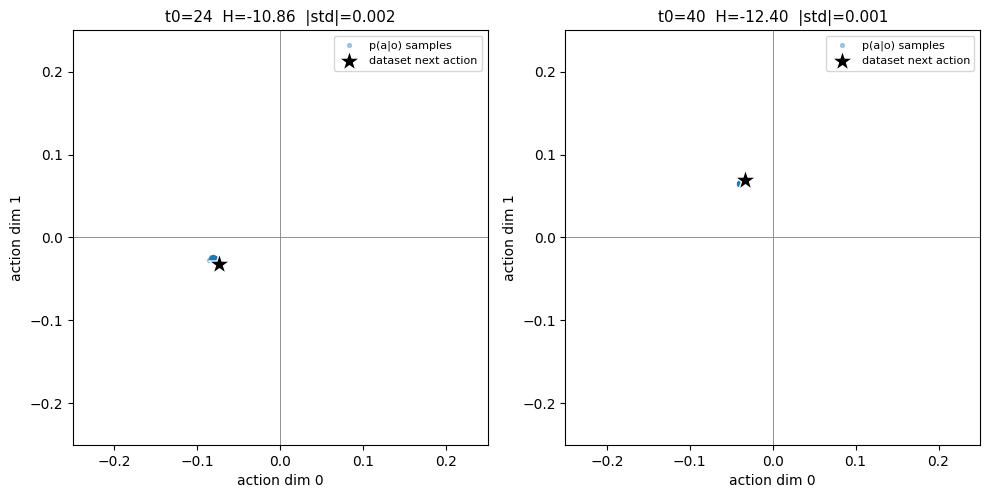

In [15]:
fig, axes = plt.subplots(1, len(STATES), figsize=(5.0 * len(STATES), 5.0))
axes = np.atleast_1d(axes)
for ax, t0 in zip(axes, STATES):
    ctx_z, ctx_a, gt = make_state(t0)
    a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                       n_samples=N_SAMPLES, K=K_STEPS, max_batch=MAX_BATCH)[:, 0]
    s = summarize(a0)
    plot_action_clouds({'p(a|o) samples': a0.cpu().numpy()},
                       gt=gt[0].cpu().numpy(),
                       title=f't0={t0}  H={s["entropy"]:.2f}  |std|={s["trace_std"]:.3f}',
                       ax=ax)
plt.tight_layout(); plt.show()

Optionally, look at the state image the policy is conditioned on (last
context frame) next to its action cloud.

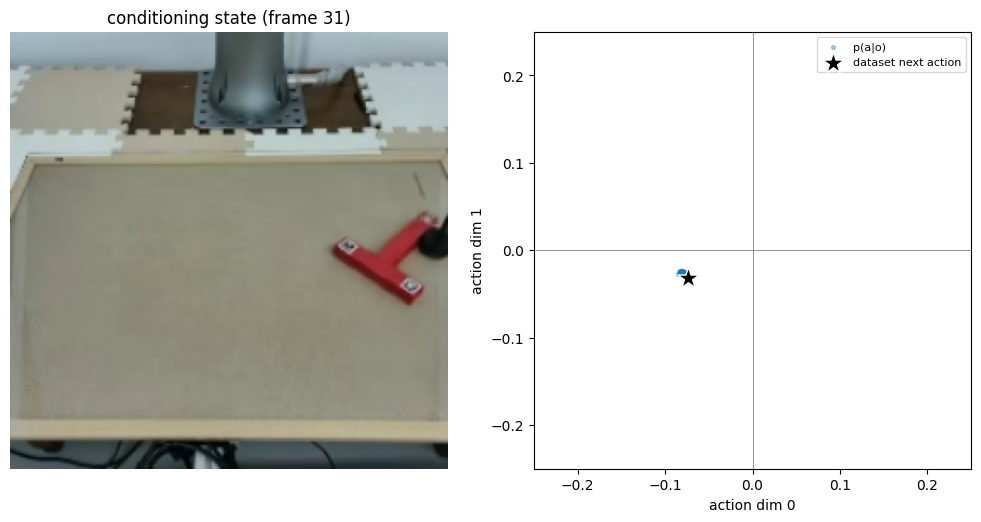

In [16]:
t0 = 24
ctx_z, ctx_a, gt = make_state(t0)
a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                   n_samples=N_SAMPLES, K=K_STEPS, max_batch=MAX_BATCH)[:, 0]
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(decode_frame(ctx_z[:, -1:])); ax[0].axis('off')
ax[0].set_title(f'conditioning state (frame {t0 + T_ctx - 1})')
plot_action_clouds({'p(a|o)': a0.cpu().numpy()}, gt=gt[0].cpu().numpy(), ax=ax[1])
plt.tight_layout(); plt.show()

# Part II — Context-noise injection → action diversity

Sweep `ctx_noise` and measure action entropy. Same initial action prior across
levels (`seed` fixed), so differences reflect the *conditioning*, not sampling
variance.

**Hypothesis.** Honest noise tells the model the state is uncertain, widening the
posterior `p(a | noisy o)` → higher entropy. Mismatched noise (corrupt but claim
clean) may instead push the model out of distribution.

In [17]:
t0 = 24
ctx_z, ctx_a, gt = make_state(t0)

clouds, ent_honest = {}, []
for n in NOISES:
    a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                       n_samples=N_SAMPLES, K=K_STEPS, max_batch=MAX_BATCH,
                       ctx_noise=n, ctx_noise_honest=True, seed=0)[:, 0]
    clouds[f'n={n}'] = a0.cpu().numpy()
    ent_honest.append(summarize(a0)['entropy'])
    print(f'[honest] ctx_noise={n:.2f}  entropy={ent_honest[-1]:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
plot_action_clouds(clouds, gt=gt[0].cpu().numpy(), title='honest context noise', ax=ax[0])
ax[1].plot(NOISES, ent_honest, 'o-'); ax[1].set_xlabel('ctx_noise (n)')
ax[1].set_ylabel('Gaussian entropy (nats)'); ax[1].grid(alpha=.3)
ax[1].set_title('action entropy vs context noise')
plt.tight_layout(); plt.show()

[honest] ctx_noise=0.00  entropy=-10.863


KeyboardInterrupt: 

## Honest vs mismatched noise

Compare the entropy curve when the model is *told* about the noise vs when the
context is corrupted but announced clean.

In [ ]:
ent_mismatch = []
for n in NOISES:
    a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                       n_samples=N_SAMPLES, K=K_STEPS, max_batch=MAX_BATCH,
                       ctx_noise=n, ctx_noise_honest=False, seed=0)[:, 0]
    ent_mismatch.append(summarize(a0)['entropy'])
    print(f'[mismatch] ctx_noise={n:.2f}  entropy={ent_mismatch[-1]:.3f}')

plt.figure(figsize=(6, 4))
plt.plot(NOISES, ent_honest, 'o-', label='honest (sigma told)')
plt.plot(NOISES, ent_mismatch, 's--', label='mismatched (claim clean)')
plt.xlabel('ctx_noise (n)'); plt.ylabel('Gaussian entropy (nats)')
plt.legend(); plt.grid(alpha=.3); plt.title('entropy vs context noise')
plt.tight_layout(); plt.show()

# Part III — Other diversity knobs

**Action-prior temperature.** Flow matching transports the *prior* `N(0, I)` to
`p(a|o)`; scaling the prior std is a temperature-like control. Note `std != 1`
feeds the model a prior it never saw at training (slightly OOD), so watch for
distortion rather than clean entropy increase.

In [ ]:
t0 = 24
ctx_z, ctx_a, gt = make_state(t0)

clouds, ent_temp = {}, []
for s in TEMPS:
    a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                       n_samples=N_SAMPLES, K=K_STEPS, max_batch=MAX_BATCH,
                       action_noise_std=s, seed=0)[:, 0]
    clouds[f'std={s}'] = a0.cpu().numpy()
    ent_temp.append(summarize(a0)['entropy'])
    print(f'action_noise_std={s}  entropy={ent_temp[-1]:.3f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 5))
plot_action_clouds(clouds, gt=gt[0].cpu().numpy(), title='action-prior temperature', ax=ax[0])
ax[1].plot(TEMPS, ent_temp, 'o-'); ax[1].set_xlabel('action_noise_std')
ax[1].set_ylabel('entropy (nats)'); ax[1].grid(alpha=.3); ax[1].set_title('entropy vs temperature')
plt.tight_layout(); plt.show()

**Diffusion steps `K`.** More Euler steps → tighter integration. Does the
cloud sharpen (lower entropy) or stay stable as K grows?

In [ ]:
ent_K = []
for K in KS:
    a0 = policy_sample(denoiser, ctx_z, ctx_a, horizon=1,
                       n_samples=N_SAMPLES, K=K, max_batch=MAX_BATCH, seed=0)[:, 0]
    ent_K.append(summarize(a0)['entropy'])
    print(f'K={K:3d}  entropy={ent_K[-1]:.3f}')
plt.figure(figsize=(6, 4))
plt.plot(KS, ent_K, 'o-'); plt.xscale('log', base=2)
plt.xlabel('diffusion steps K'); plt.ylabel('entropy (nats)')
plt.grid(alpha=.3); plt.title('action entropy vs K'); plt.tight_layout(); plt.show()

# Part IV — Toward MCTS edges: short action rollouts

An MCTS edge is a short action rollout from `π_prior`. Sample `H`-step action
sequences (open-loop: all conditioned on the same current state, horizon states
held at noise) and look at their divergence — this is the *raw* edge diversity
before the world model rolls states forward.

In [ ]:
t0 = 24
ctx_z, ctx_a, gt = make_state(t0)
H, NB = ROLL_H, ROLL_NB
rolls = policy_sample(denoiser, ctx_z, ctx_a, horizon=H,
                      n_samples=NB, K=K_STEPS, max_batch=MAX_BATCH, seed=0)  # (NB, H, n_act)
r = rolls.cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for b in range(NB):
    ax[0].plot(r[b, :, 0], alpha=.6, lw=1)
    ax[1].plot(r[b, :, 1], alpha=.6, lw=1)
ax[0].set_title('action dim 0 over rollout'); ax[1].set_title('action dim 1 over rollout')
for a_ in ax:
    a_.set_xlabel('step'); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

# per-step spread of the rollout bundle
step_std = rolls.std(0).norm(dim=-1).cpu().numpy()   # (H,)
print('per-step rollout spread (|std|):', np.round(step_std, 3))

# Remarks & next ideas

**On these experiments**
- *Diversity source.* Flow matching is a deterministic ODE from the prior to
  `p(a|o)`; all stochasticity comes from the initial action noise (and the
  context-noise draw). So "entropy of `p(a|o)`" is exactly the spread of the
  integrated samples — what we measure here.
- *Honest vs mismatched context noise.* Honest noise is the principled knob (it
  asks the model for its posterior under a noisier observation). Mismatched noise
  is OOD and may degrade rather than diversify — useful as a contrast only.
- *Temperature caveat.* `action_noise_std != 1` is off-distribution; prefer
  honest context noise or a learned-temperature scheme if entropy must be tuned.

**Toward MCTS**
1. *Useful diversity = downstream state coverage.* Action entropy alone isn't the
   target — diverse actions that lead to the *same* state don't help search.
   Decode each sampled action rollout through the **world model** (state-mode /
   `ray_sampler` with actions clean, state integrated) and measure spread in
   **latent state space**. That's the real edge-diversity metric.
2. *Closed-loop edges.* The rollouts here are open-loop (all steps see only the
   current state). A faithful `π_prior` edge alternates policy→WM→policy with the
   KV cache. Worth building on top of `HybridChunkSampler`.
3. *Calibration to data.* Compare `p(a|o)` entropy to the empirical action
   entropy in the dataset around matched states — is the policy over/under-
   dispersed?
4. *Mode coverage.* At genuinely bimodal states (push left vs right around the T),
   check whether the cloud is bimodal or collapses to one mode; a Gaussian
   entropy number hides this — add a 2-D KDE / GMM fit.
5. *Guidance for exploration.* CFG-style negative guidance away from the
   most-likely action, or sampling at higher action `tau` start, could be a
   cheaper exploration knob than context noise.
6. *Value/reward head.* The denoiser supports a reward MTP head
   (`train_reward_model`); once enabled, MCTS edge selection can use predicted
   returns directly from the same model.